# Обучение моделей на основе деревьев

In [ ]:
# Библиотеки
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
current_dir = Path.cwd()
file_path = current_dir.parent / "data" / "raw_data.csv"
train = pd.read_csv(file_path)

## 1. Дерево решений (Decision Tree Classifier)

### 1.1. Подготовка данных и деление на выборки

По результатам EDA было решено убрать столбец N_Days (количество дней нахождения пациента под наблюдением - не влияет на результат) и убрать третий целевой класс (CL - пациент выбыл из наблюдения вследствие трансплантации печени)

In [3]:
train = train.drop(['id', 'N_Days'], axis=1)
train = train[train['Status'] != 'CL']

In [4]:
# Категориальные признаки для кодирования (без целевого признака)
cat_columns = train.select_dtypes(include=['object']).columns
cat_columns = cat_columns.drop('Status')

# Кодируем категориальные признаки
encoded_train = pd.get_dummies(
    train, columns=cat_columns, prefix=cat_columns, drop_first=True)

# Отдельно кодируем целевой признак: С 0, D 1.
status_mapping = {'C': 0, 'D': 1} 
encoded_train['Status'] = encoded_train['Status'].map(status_mapping)

In [5]:
# Разделение на train и test со стратификацией
X = encoded_train.drop('Status', axis=1)
y = encoded_train['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Размер тренировочных данных: {X_train.shape}')
print(f'Размер тестовых данных: {X_test.shape}')
print('')
print(f'Целевая переменная в train (проценты):\n {(y_train.value_counts(normalize=True) * 100).round(0)}')
print(f'Целевая переменная в test (проценты):\n {(y_test.value_counts(normalize=True) * 100).round(0)}')

Train set: (6104, 18)
Test set: (1526, 18)
Размер тренировочных данных: (6104, 18)
Размер тестовых данных: (1526, 18)

Целевая переменная в train (проценты):
 Status
0    65.0
1    35.0
Name: proportion, dtype: float64
Целевая переменная в test (проценты):
 Status
0    65.0
1    35.0
Name: proportion, dtype: float64


### 1.2. Baseline и гиперпараметры

Лучшие параметры модели: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучшее качество на кросс-валидации (f1): 0.7878751939211802

Оценка на кросс-валидации:


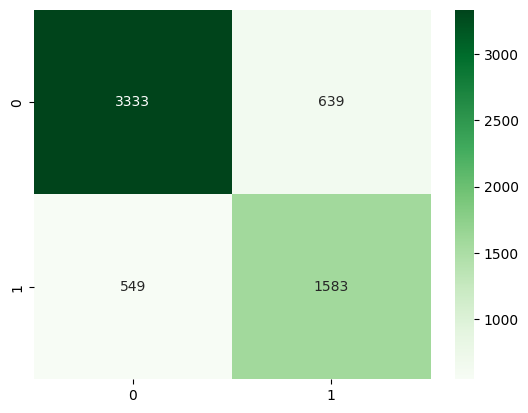

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      3972
           1       0.71      0.74      0.73      2132

    accuracy                           0.81      6104
   macro avg       0.79      0.79      0.79      6104
weighted avg       0.81      0.81      0.81      6104



In [6]:
# Для кросс-валидации
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Базовая модель с балансировкой классов
model = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Параметры для перебора
params = {
    'max_depth': range(1, 20),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': range(1, 10)
}

# Обучаем Grid Search
grid_search_dt = GridSearchCV(
    model, param_grid=params, cv=skf, scoring='f1_macro', n_jobs=-1
)
grid_search_dt.fit(X_train, y_train)

# Лучшая модель
best_dt_model = grid_search_dt.best_estimator_

# Предсказания на кросс-валидации
y_pred = cross_val_predict(best_dt_model, X_train, y_train, cv=skf, n_jobs=-1)

print(f'Лучшие параметры модели: {grid_search_dt.best_params_}')
print(f'Лучшее качество на кросс-валидации (f1): {grid_search_dt.best_score_}')
print('')
print('Оценка на кросс-валидации:')
sns.heatmap(confusion_matrix(y_train, y_pred), annot=True, fmt='d',  cmap='Greens')
plt.show()
report_cv = classification_report(y_train, y_pred)
print(report_cv)

**Результаты Decision Tree Classifier (baseline):** Средняя оценка F1 на кросс-валидации **0.78** (класс 0 - 0.85, класс 1 - 0.73)

#### 1.2.1. Feature importance

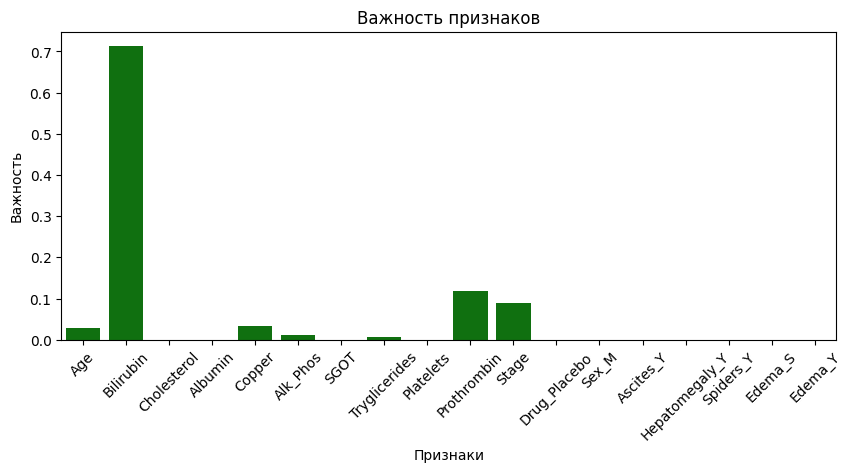

In [7]:
feature = X.columns
feature_importances = best_dt_model.feature_importances_

plt.figure(figsize=(10, 4))
sns.barplot(x=feature, y=feature_importances, color='Green')

plt.title('Важность признаков')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45)
plt.show()

Лучшие параметры модели: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучшее качество на кросс-валидации (f1): 0.7905789771313041

Оценка на кросс-валидации:


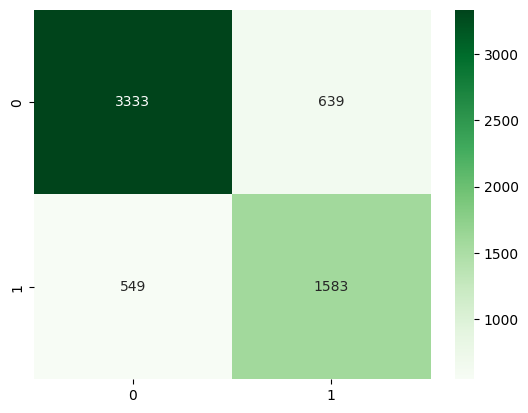

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      3972
           1       0.71      0.74      0.73      2132

    accuracy                           0.81      6104
   macro avg       0.79      0.79      0.79      6104
weighted avg       0.81      0.81      0.81      6104



In [8]:
# Попробуем только важные для модели признаки
cols = ['Bilirubin', 'Age', 'Copper', 'Alk_Phos', 'Tryglicerides', 'Prothrombin', 'Stage']
X_cols = X_train[cols]

# Обучаем
grid_search_dt.fit(X_cols, y_train)

# Лучшая модель
featured_best_dt_model = grid_search_dt.best_estimator_

# Предсказания на кросс-валидации
y_pred = cross_val_predict(best_dt_model, X_train, y_train, cv=skf, n_jobs=-1)

print(f'Лучшие параметры модели: {grid_search_dt.best_params_}')
print(f'Лучшее качество на кросс-валидации (f1): {grid_search_dt.best_score_}')
print('')
print('Оценка на кросс-валидации:')
sns.heatmap(confusion_matrix(y_train, y_pred), annot=True, fmt='d',  cmap='Greens')
plt.show()
report_cv = classification_report(y_train, y_pred)
print(report_cv)


**Результаты Decision Tree Classifier (отбор важных признаков):** Средняя оценка F1 на кросс-валидации **0.79** (класс 0 - 0.85, класс 1 - 0.73)

## 2. Случайный лес (Random Forest Classifier)

### 2.1. Baseline и гиперпараметры

In [ ]:
# Базовая модель с балансировкой классов
model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Параметры для перебора
params = {
    'n_estimators': range(1, 50),
    'max_depth': range(1, 10),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': range(1, 10)
}

# Обучаем Grid Search
grid_search_rf = GridSearchCV(
    model, param_grid=params, cv=skf, scoring='f1_macro', n_jobs=-1
)
grid_search_rf.fit(X_train, y_train)

# Лучшая модель
best_rf_model = grid_search_rf.best_estimator_

# Предсказания на кросс-валидации
y_pred = cross_val_predict(best_rf_model, X_train, y_train, cv=skf, n_jobs=-1)

print(f'Лучшие параметры модели: {grid_search_rf.best_params_}')
print(f'Лучшее качество на кросс-валидации (f1): {grid_search_rf.best_score_}')
print('')
print('Оценка на кросс-валидации:')
sns.heatmap(confusion_matrix(y_train, y_pred), annot=True, fmt='d',  cmap='Greens')
plt.show()
report_cv = classification_report(y_train, y_pred)
print(report_cv)

KeyboardInterrupt: 

**Результаты Decision Tree Classifier (baseline):** Средняя оценка F1 на кросс-валидации **0.82** (класс 0 - 0.88, класс 1 - 0.77)

In [ ]:
feature_importances = best_rf_model.feature_importances_

plt.figure(figsize=(10, 4))
sns.barplot(x=feature, y=feature_importances, color='Green')

plt.title('Важность признаков')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Попробуем только важные для модели признаки
cols = ['Bilirubin', 'Age', 'Copper', 'SGOT', 'Prothrombin', 'Stage', 'Hepatomegaly_Y']
X_cols = X_train[cols]

# Обучаем
grid_search_rf.fit(X_cols, y_train)

# Лучшая модель
featured_best_rf_model = grid_search_rf.best_estimator_

# Предсказания на кросс-валидации
y_pred = cross_val_predict(best_dt_model, X_train, y_train, cv=skf, n_jobs=-1)

print(f'Лучшие параметры модели: {grid_search_rf.best_params_}')
print(f'Лучшее качество на кросс-валидации (f1): {grid_search_rf.best_score_}')
print('')
print('Оценка на кросс-валидации:')
sns.heatmap(confusion_matrix(y_train, y_pred), annot=True, fmt='d',  cmap='Greens')
plt.show()
report_cv = classification_report(y_train, y_pred)
print(report_cv)